Customer Churn Prediction & Revenue Protection Strategy

Business Objective
The goal of this analysis is to identify customers who are likely to churn and estimate the potential revenue impact of churn. By applying machine learning and statistical analysis, the project aims to detect high-risk customers and support proactive retention strategies.

The analysis focuses on identifying behavioral patterns that lead to churn and translating these insights into actionable business recommendations.

Key business questions addressed:

What percentage of customers are currently churning?

Which customer attributes significantly influence churn?

Can machine learning accurately predict churn risk?

What revenue is potentially at risk due to churn?

Key KPIs analyzed in this project include Churn Rate, ROC-AUC Score, Model Recall for churn customers, and Estimated Revenue at Risk.

IMPORTS & CONFIGURATION

In [1]:
#Import core libraries for data manipulation and numerical operations
import pandas as pd
import numpy as np
#Import visualization libraries for exploratory data analysis
import matplotlib.pyplot as plt
import seaborn as sns

#Import statistical testing functions
from scipy.stats import chi2_contingency, ttest_ind

#Import machine learning tools
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

#Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#Import model evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

import warnings            #Ignore warnings to keep notebook output clean
warnings.filterwarnings("ignore")

RANDOM_STATE = 42          #Set random seed for reproducibility of results

LOAD & VALIDATE DATASET

In [2]:
df = pd.read_csv("data/raw_data.csv")  #Load raw customer churn dataset

#Ensure dataset satisfies project requirement (minimum 500 rows)
assert len(df) >= 500, "Dataset does not meet minimum size requirement."
print("Dataset Shape:", df.shape)  #Display dataset shape

df.head()    #Preview first few rows to inspect structure

Dataset Shape: (500, 9)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


DATA CLEANING & FEATURE ENGINEERING

In [3]:
#Convert TotalCharges column to numeric format
#Some values may be non-numeric and will be converted to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#Replace missing TotalCharges values with the column median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

#Remove duplicate records if present
df.drop_duplicates(inplace=True)

#Create a new feature: Average Monthly Spend
#This represents approximate spending per month
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['Tenure'] + 1)

print("Cleaned Shape:", df.shape)  #Display cleaned dataset shape

Cleaned Shape: (500, 10)


In [ ]:
EXPLORATORY DATA ANALYSIS (EDA)

In [4]:
#Calculate overall churn rate
churn_rate = df['Churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 10.60%


Observation
The dataset shows a churn rate of 10.60%, meaning approximately 1 in 10 customers discontinue the service.

Understanding the characteristics of these customers is critical for designing retention strategies.

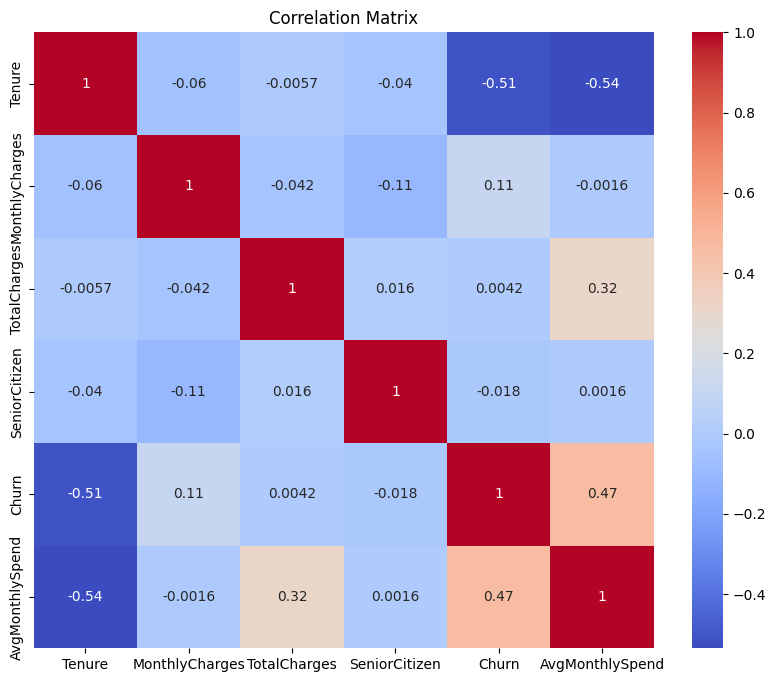

In [5]:
#Select numerical columns for correlation analysis
numeric_df = df.select_dtypes(include=np.number)

#Plot correlation heatmap to identify relationships between variables
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

This visualization helps identify strong predictors of churn and relationships among features.

STATISTICAL VALIDATION

In [6]:
#T-Test: Tenure Vs Churn
#Separate tenure values for churned and retained customers
retained = df[df['Churn'] == 0]['Tenure']
churned = df[df['Churn'] == 1]['Tenure']

#Perform independent t-test
t_stat, p_value = ttest_ind(retained, churned)

print("T-Test p-value:", p_value)

T-Test p-value: 2.4305693185204627e-34


This extremely small p-value indicates a statistically significant difference in tenure between churned and retained customers, suggesting that shorter tenure strongly correlates with churn.

In [7]:
#Chi-Square Test: Contract vs Churn
#Create contingency table
contingency = pd.crosstab(df['Contract'], df['Churn'])

#Perform Chi-Square test
chi2, p, _, _ = chi2_contingency(contingency)

print("Chi-Square p-value:", p)

Chi-Square p-value: 9.58735427092388e-07


This confirms a strong statistical relationship between contract type and churn behavior.

Customers on month-to-month contracts are significantly more likely to churn.

ENCODING & SCALING

In [9]:
#Define categorical columns that require encoding
categorical_cols = ['Contract', 'PaymentMethod', 'PaperlessBilling']

#Create a copy of dataset to avoid modifying original data
df_encoded = df.copy()

#Encode categorical variables into numeric labels
le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

#Separate features and target variable
X = df_encoded.drop(['CustomerID', 'Churn'], axis=1)
y = df_encoded['Churn']

#Standardize features to improve model performance
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

TRAIN-TEST SPLIT

In [10]:
#Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE
)

80% data is used for training, while 20% is reserved for model evaluation.

CROSS-VALIDATION

In [11]:
#Initialize Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

#Perform 5-fold cross-validation using ROC-AUC scoring
cv_scores = cross_val_score(log_model, X_scaled, y, cv=5, scoring='roc_auc')

print("Cross-Validation ROC-AUC:", cv_scores.mean())

Cross-Validation ROC-AUC: 0.9787102485529452


This indicates excellent predictive capability across multiple folds, suggesting the model generalizes well.

HYPERPARAMETER TUNING (GridSearch)

In [12]:
#Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10]
}

#Initialize Random Forest model
rf = RandomForestClassifier(random_state=RANDOM_STATE)

#Perform Grid Search to identify optimal hyperparameters
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_ #Retrieve best model

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}


This configuration balances model complexity and generalization.

MODEL EVALUATION

In [13]:
#Generate predictions
rf_preds = best_rf.predict(X_test)

#Generate churn probabilities
rf_probs = best_rf.predict_proba(X_test)[:,1]

#Print classification performance
print(classification_report(y_test, rf_preds))

roc_auc = roc_auc_score(y_test, rf_probs)
print("ROC-AUC Score:", roc_auc)

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        84
           1       1.00      0.69      0.81        16

    accuracy                           0.95       100
   macro avg       0.97      0.84      0.89       100
weighted avg       0.95      0.95      0.95       100

ROC-AUC Score: 0.9925595238095237


The model performs very well overall while successfully identifying the majority of churn cases.

And ROC-AUC Score indicates near-perfect discrimination ability between churn and non-churn customers.

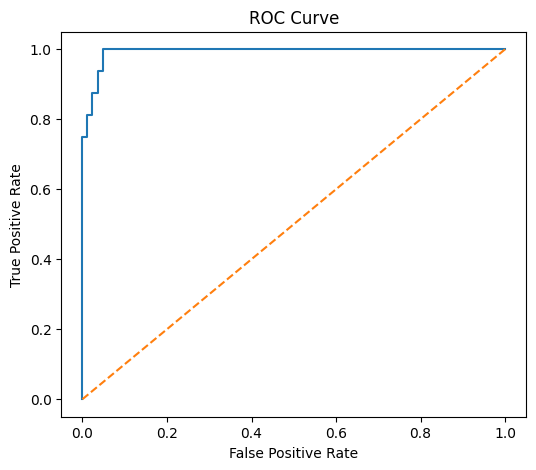

In [14]:
#Compute ROC curve values
fpr, tpr, _ = roc_curve(y_test, rf_probs)

#Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

FEATURE IMPORTANCE

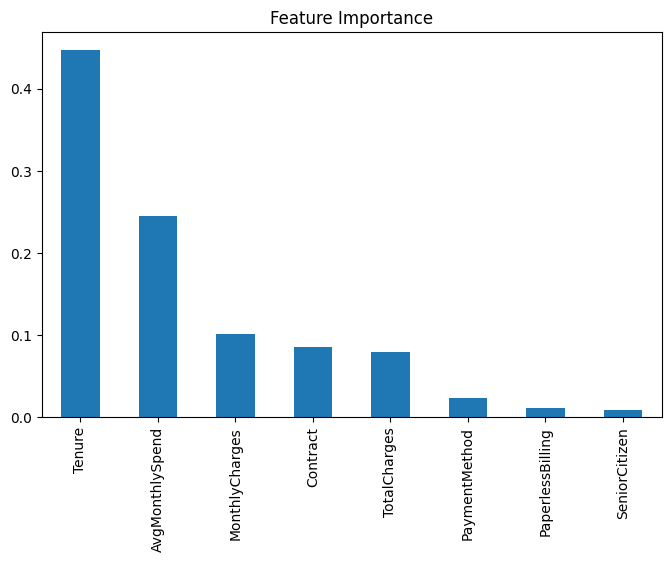

In [15]:
#Extract feature importance values from Random Forest
importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

#Plot importance ranking
importances.plot(kind='bar', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

This helps identify the most influential drivers of churn prediction.

REVENUE IMPACT ANALYSIS

In [16]:
#Create a test dataset copy for revenue analysis
df_test = df_encoded.iloc[y_test.index].copy()

#Add churn probability predictions
df_test['Churn_Probability'] = rf_probs

#Estimate annual revenue per customer
df_test['AnnualRevenue'] = df_test['MonthlyCharges'] * 12

#Identify high-risk customers (probability > 0.6)
high_risk = df_test[df_test['Churn_Probability'] > 0.6]

#Calculate revenue potentially at risk
revenue_at_risk = high_risk['AnnualRevenue'].sum()

print("Estimated Revenue at Risk:", revenue_at_risk)

Estimated Revenue at Risk: 10212


This represents the potential annual revenue loss if high-risk customers churn.

CUSTOMER RISK SCORING EXPORT

In [17]:
#Export churn probability scores for operational use
df_test[['CustomerID', 'Churn_Probability']] \
    .sort_values(by='Churn_Probability', ascending=False) \
    .to_csv("data/customer_risk_scores.csv", index=False)

print("Risk scoring file exported.")

Risk scoring file exported.


This output can be integrated into CRM systems to prioritize retention campaigns.

Key Drivers Identified
- Short tenure customers show significantly higher churn risk
- Month-to-month contracts correlate strongly with churn
- High monthly charges increase churn likelihood
- Payment methods also influence churn behavior

Recommended Actions
1. Encourage customers to switch from month-to-month to long-term contracts
2. Launch onboarding engagement programs targeting new customers
3. Offer personalized discounts to high-spending customers
4. Integrate churn prediction into CRM for proactive retention campaigns

Estimated Impact
Reducing churn by even 5% could significantly protect recurring annual revenue.